# Conical Scanner Validation: GPM GMI

This notebook validates TAT-C's `ConicalInstrument` against a second conically scanning radiometer: the [GPM Microwave Imager (GMI)](https://gpm.nasa.gov/missions/GPM/GMI) aboard the Global Precipitation Measurement (GPM) Core Observatory. GMI's antenna rotates once every 1.875 s, observing an arc ahead of the satellite during part of each rotation, like AMSR2 (see [Conical Scanner Validation: AMSR2](ValidateConicalAMSR2.ipynb), which motivated the `ConicalInstrument`). GMI differs from AMSR2 in ways that test the generality of the model:

* **Two cones.** Its low-frequency channels (10 to 89 GHz) and high-frequency channels (166 and 183 GHz) use separate feeds that view the ground at different incidence angles (about 53 and 49 deg), so GMI is modeled as two `ConicalInstrument`s on one satellite.
* **Orbit.** GPM flies a non-sun-synchronous orbit inclined 65 deg at about 440 km altitude (raised from 400 km in 2023), so the scan's cone angle, sector, and swath differ from AMSR2's, and observation times drift through the day.

The comparison asks five questions:

1. **Orbit.** Does TAT-C's propagation of a public two-line element (TLE) set reproduce GPM's position?
2. **Scan geometry.** What cone angles, scan sectors, and orientation describe GMI's two feeds?
3. **Footprints.** Do the conical instruments' footprints and swath widths match the scanned arcs?
4. **Observations.** Does `collect_observations` predict which points GMI observes in a day, and when?
5. **Swath coverage.** Do the footprints from `compute_ground_track` reproduce the area GMI scans over an orbit?

## Reference Data

The GPM Level 1C GMI product ([`GPM_1CGPMGMI`](https://disc.gsfc.nasa.gov/datasets/GPM_1CGPMGMI_08/summary), version 08), distributed by the NASA Goddard Earth Sciences Data and Information Services Center (GES DISC), holds one file per orbit with, for each of two groups of channels (`S1`, low frequency, and `S2`, high frequency; 221 samples per scan), the geodetic latitude and longitude of every footprint, the scan time, and the spacecraft's geodetic position and flight orientation at each scan.

All orbits on 3 October 2026 are downloaded (requiring a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package) and reduced to a cache in a local `data/gmi` directory.

GPM is modeled with a TLE from [CelesTrak](https://celestrak.org/) whose epoch (4 October 2026, 13:00 UTC) follows the analysis day by up to about a day and a half.

In [1]:
import io
from datetime import datetime, timezone
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "gmi"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DAY = datetime(2026, 10, 3, tzinfo=timezone.utc)
TLE = [
    "1 39574U 14009C   26277.54227627  .00004528  00000+0  10004-3 0  9997",
    "2 39574  64.9701 301.6724 0010793 268.6572  91.3332 15.45217995714704",
]
FEEDS = {"S1": "low frequency", "S2": "high frequency"}
CACHE_FILE = DATA_DIR / f"gmi_l1c_{DAY:%Y%m%d}.npz"

if not CACHE_FILE.exists():
    import earthaccess

    earthaccess.login()
    session = earthaccess.get_requests_https_session()
    granules = requests.get(
        "https://cmr.earthdata.nasa.gov/search/granules.umm_json",
        params={
            "short_name": "GPM_1CGPMGMI",
            "version": "08",
            "temporal": f"{DAY:%Y-%m-%d}T00:00:00Z,{DAY:%Y-%m-%d}T23:59:59Z",
            "page_size": 100,
        },
        timeout=120,
    ).json()["items"]
    urls = [next(u["URL"] for u in g["umm"]["RelatedUrls"] if u["URL"].startswith("https://data.gesdisc")) for g in granules]
    parts = []
    for url in urls:
        with h5py.File(io.BytesIO(session.get(url, timeout=900).content)) as f:
            s1 = f["S1"]
            seconds = (
                pd.to_datetime(
                    pd.DataFrame(
                        {
                            "year": s1["ScanTime/Year"][:],
                            "month": s1["ScanTime/Month"][:],
                            "day": s1["ScanTime/DayOfMonth"][:],
                            "hour": s1["ScanTime/Hour"][:],
                            "minute": s1["ScanTime/Minute"][:],
                            "second": s1["ScanTime/Second"][:],
                            "ms": s1["ScanTime/MilliSecond"][:],
                        }
                    ),
                    utc=True,
                )
                - pd.Timestamp(DAY)
            ).dt.total_seconds().to_numpy()
            parts.append(
                {
                    "time": seconds,
                    "sc_lat": s1["SCstatus/SClatitude"][:],
                    "sc_lon": s1["SCstatus/SClongitude"][:],
                    "sc_alt": s1["SCstatus/SCaltitude"][:],
                    "orientation": s1["SCstatus/SCorientation"][:],
                    **{f"{feed}_lat": f[f"{feed}/Latitude"][:] for feed in FEEDS},
                    **{f"{feed}_lon": f[f"{feed}/Longitude"][:] for feed in FEEDS},
                }
            )
    reduced = {k: np.concatenate([p[k] for p in parts]) for k in parts[0]}
    # keep each scan once (orbit files overlap), in time order, within the day
    _, first = np.unique(reduced["time"], return_index=True)
    keep = first[(reduced["time"][first] >= 0) & (reduced["time"][first] < 86400)]
    np.savez_compressed(CACHE_FILE, granules=len(urls), **{k: v[keep] for k, v in reduced.items()})

gmi = dict(np.load(CACHE_FILE))
pd.Series(
    {
        "orbit files": int(gmi["granules"]),
        "scans": len(gmi["time"]),
        "samples per scan": gmi["S1_lat"].shape[1],
        "flight orientations": ", ".join(str(o) for o in np.unique(gmi["orientation"])),
    }
)

orbit files               16
scans                  46081
samples per scan         221
flight orientations        0
dtype: object

## Setup

As in the AMSR2 notebook, times count seconds since 00:00 UTC on the analysis day, the spacecraft's Earth-fixed position is computed from its reported geodetic position at each scan, and its velocity by differencing positions. Scans with missing footprints (fill values) are excluded. GPM flew forward (flight orientation 0) throughout the day.

In [2]:
from datetime import timedelta

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Geod, Transformer
from scipy.spatial import cKDTree
from shapely import contains_xy, prepare
from skyfield.framelib import itrs

from tatc.analysis import collect_observations, compute_ground_track
from tatc.constants import EARTH_ROTATION_RATE
from tatc.generation import generate_points_fibonacci_lattice
from tatc.schemas import ConicalInstrument, GeneralPerturbationsOrbit, Instrument, Point, Satellite
from tatc.utils import VelocityFrame

GEOD = Geod(ellps="WGS84")
TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
gpm = Satellite(name="GPM", orbit=GeneralPerturbationsOrbit.from_tle(TLE))
orbit = gpm.orbit.to_gp_orbit()


def to_utc(seconds):
    return [DAY + timedelta(seconds=float(s)) for s in np.atleast_1d(seconds)]


def ecef(lon, lat, height=0.0):
    """Earth-fixed position (m) of geodetic coordinates, stacked on the last axis."""
    return np.stack(TO_ECEF.transform(lon, lat, np.broadcast_to(height, np.shape(lon))), axis=-1)


def up(lon, lat):
    """Geodetic up unit vector, stacked on the last axis."""
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)


def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def inertial_velocity(position, velocity):
    """Inertial velocity expressed in Earth-fixed coordinates."""
    return velocity + EARTH_ROTATION_RATE * np.stack([-position[..., 1], position[..., 0], np.zeros(position.shape[:-1])], axis=-1)


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


def binned(x, y, edges, q=(5, 50, 95)):
    """Percentiles of y in bins of x."""
    i = np.digitize(x, edges) - 1
    return np.array([np.percentile(y[i == k], q) if np.any(i == k) else [np.nan] * len(q) for k in range(len(edges) - 1)])


valid = np.all([np.all(np.abs(gmi[f"{feed}_lat"]) <= 90, axis=1) for feed in FEEDS], axis=0)
scan_time = gmi["time"][valid]
sc_pos = ecef(gmi["sc_lon"][valid].astype(float), gmi["sc_lat"][valid].astype(float), gmi["sc_alt"][valid].astype(float) * 1e3)
sc_vel = np.gradient(sc_pos, scan_time, axis=0)
contiguous = np.r_[np.diff(scan_time) < 3, False] & np.r_[False, np.diff(scan_time) < 3]
foot = {feed: (gmi[f"{feed}_lon"][valid].astype(float), gmi[f"{feed}_lat"][valid].astype(float)) for feed in FEEDS}
gaps = [(scan_time[i], scan_time[i + 1]) for i in np.nonzero(np.diff(scan_time) > 60)[0]]
N_SAMPLES = foot["S1"][0].shape[1]

BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
FEED_COLORS = {"S1": BLUE, "S2": ORANGE}
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)
pd.Series(
    {
        "scans used": len(scan_time),
        "scans excluded (fill values)": int((~valid).sum()),
        "scan period (s)": np.median(np.diff(scan_time)),
        "data gaps longer than 1 minute": len(gaps),
        "altitude range (km)": f"{gmi['sc_alt'].min():.0f} to {gmi['sc_alt'].max():.0f}",
    }
)

scans used                             46081
scans excluded (fill values)               0
scan period (s)                        1.875
data gaps longer than 1 minute             0
altitude range (km)               432 to 448
dtype: object

## Test 1: Orbit

TAT-C's propagated position is compared with the reported spacecraft position at every fiftieth scan, with residuals decomposed along the velocity, to its right, and radially.

In [3]:
i1 = np.nonzero(contiguous)[0][::50]
p1 = np.array(orbit.get_orbit_track(to_utc(scan_time[i1])).frame_xyz_and_velocity(itrs)[0].m).T
offset1 = p1 - sc_pos[i1]
radial1 = normalize(sc_pos[i1])
along1 = normalize(sc_vel[i1] - np.sum(sc_vel[i1] * radial1, axis=-1, keepdims=True) * radial1)
pd.DataFrame(
    {
        "along-track (km)": summarize(np.sum(offset1 * along1, axis=-1) / 1e3),
        "cross-track, right (km)": summarize(np.sum(offset1 * np.cross(along1, radial1), axis=-1) / 1e3),
        "radial (km)": summarize(np.sum(offset1 * radial1, axis=-1) / 1e3),
    }
).T.round(3)

,n,median,p95 |x|,max |x|
along-track (km),922.0,-4.185,4.866,5.140
"cross-track, right (km)",922.0,0.016,0.446,0.489
radial (km),922.0,-0.019,0.307,0.360


The propagated TLE trails the reported positions by 4.2 km (median), a day or more before the TLE epoch, with across-track and radial differences below 0.5 km. At GPM's speed relative to the ground (about 7.2 km/s), TAT-C's satellite reaches each point about 0.6 s late. This offset carries into the observation times of Test 4.

## Test 2: Scan Geometry

For every twentieth scan, the line of sight to each footprint of each feed is decomposed into a cone angle (from the geodetic nadir) and a scan azimuth (from the horizontal direction of the velocity, positive to the left), relative to both the Earth-fixed and the inertial velocity.

In [4]:
i2 = np.nonzero(contiguous)[0][::20]
sub_lon, sub_lat, sub_alt = TO_GEODETIC.transform(*sc_pos[i2].T)
nadir = -up(sub_lon, sub_lat)


def scan_angles(lon, lat, velocity):
    """Cone angle and scan azimuth (deg, positive left) of lines of sight to footprints."""
    los = normalize(ecef(lon, lat) - sc_pos[i2, None])
    cone = np.degrees(np.arccos(np.sum(los * nadir[:, None], axis=-1)))
    forward = normalize(velocity - np.sum(velocity * nadir, axis=-1, keepdims=True) * nadir)
    left = np.cross(forward, nadir)
    horizontal = los - np.sum(los * nadir[:, None], axis=-1, keepdims=True) * nadir[:, None]
    azimuth = np.degrees(np.arctan2(np.sum(horizontal * left[:, None], axis=-1), np.sum(horizontal * forward[:, None], axis=-1)))
    return cone, azimuth


geometry, rows2 = {}, {}
for feed in FEEDS:
    lon, lat = foot[feed][0][i2], foot[feed][1][i2]
    cone, azimuth_inertial = scan_angles(lon, lat, inertial_velocity(sc_pos[i2], sc_vel[i2]))
    _, azimuth_earth = scan_angles(lon, lat, sc_vel[i2])
    geometry[feed] = {
        "cone": float(np.median(cone)),
        "center": float(np.median(azimuth_inertial[:, -1] + azimuth_inertial[:, 0]) / 2),
        "half_width": float(np.median(np.abs(azimuth_inertial[:, -1] - azimuth_inertial[:, 0])) / 2),
        "azimuth": np.median(azimuth_inertial, axis=0),
        "cone_by_sample": np.median(cone, axis=0),
        "center_earth": (azimuth_earth[:, 0] + azimuth_earth[:, -1]) / 2,
        "center_inertial": (azimuth_inertial[:, 0] + azimuth_inertial[:, -1]) / 2,
    }
    chord = GEOD.inv(lon[:, 0], lat[:, 0], lon[:, -1], lat[:, -1])[2] / 1e3
    ahead = GEOD.inv(np.asarray(sub_lon), np.asarray(sub_lat), lon[:, N_SAMPLES // 2], lat[:, N_SAMPLES // 2])[2] / 1e3
    geometry[feed]["chord"] = chord
    rows2[f"{feed} ({FEEDS[feed]})"] = {
        "cone angle, median (deg)": geometry[feed]["cone"],
        "cone angle, std. dev. (deg)": np.std(cone),
        "scan sector center (deg)": geometry[feed]["center"],
        "scan sector half-width (deg)": geometry[feed]["half_width"],
        "arc center offset from Earth-fixed velocity, p95 |x| (deg)": np.percentile(np.abs(geometry[feed]["center_earth"]), 95),
        "arc center offset from inertial velocity, p95 |x| (deg)": np.percentile(np.abs(geometry[feed]["center_inertial"] - geometry[feed]["center"]), 95),
        "arc center distance ahead of nadir (km)": np.median(ahead),
        "arc end-to-end distance (swath width, km)": np.median(chord),
    }
pd.DataFrame(rows2).round(3)

,S1 (low frequency),S2 (high frequency)
"cone angle, median (deg)",48.460,45.284
"cone angle, std. dev. (deg)",0.023,0.030
scan sector center (deg),-0.285,-0.341
scan sector half-width (deg),76.031,76.024
"arc center offset from Earth-fixed velocity, p95 |x| (deg)",3.705,3.762
"arc center offset from inertial velocity, p95 |x| (deg)",0.007,0.007
arc center distance ahead of nadir (km),521.644,462.010
"arc end-to-end distance (swath width, km)",1012.283,896.509


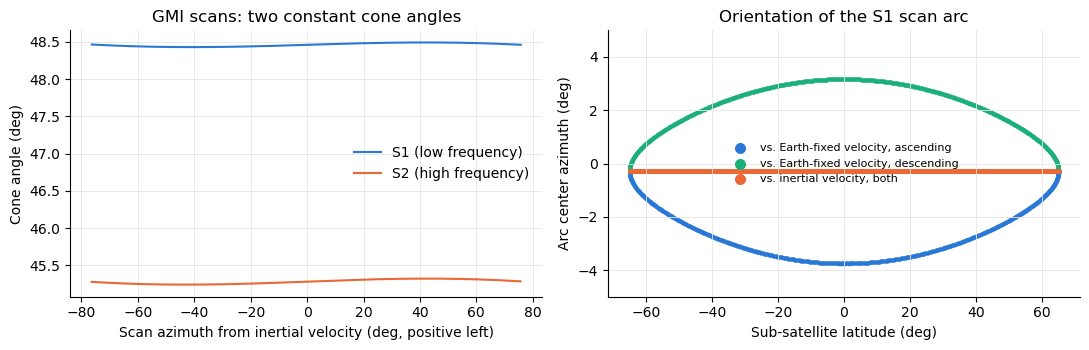

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for feed in FEEDS:
    axes[0].plot(geometry[feed]["azimuth"], geometry[feed]["cone_by_sample"], color=FEED_COLORS[feed], label=f"{feed} ({FEEDS[feed]})")
axes[0].set(xlabel="Scan azimuth from inertial velocity (deg, positive left)", ylabel="Cone angle (deg)", title="GMI scans: two constant cone angles")
axes[0].legend(frameon=False)
asc = sc_vel[i2, 2] > 0
axes[1].scatter(sub_lat[asc], geometry["S1"]["center_earth"][asc], s=3, color=BLUE, label="vs. Earth-fixed velocity, ascending")
axes[1].scatter(sub_lat[~asc], geometry["S1"]["center_earth"][~asc], s=3, color=AQUA, label="vs. Earth-fixed velocity, descending")
axes[1].scatter(sub_lat, geometry["S1"]["center_inertial"], s=3, color=ORANGE, label="vs. inertial velocity, both")
axes[1].set(xlabel="Sub-satellite latitude (deg)", ylabel="Arc center azimuth (deg)", title="Orientation of the S1 scan arc", ylim=(-5, 5))
axes[1].legend(frameon=False, fontsize=8, markerscale=4, loc="center")
fig.tight_layout()
plt.show()

Each feed scans at a constant cone angle: 48.46 deg for the low-frequency channels (S1) and 45.28 deg for the high-frequency channels (S2), varying by less than 0.1 deg across the scan and through the day. Both scan the same sector, 76.0 deg on either side of a center 0.3 deg to the right of the velocity, so their arcs are concentric: the S1 arc's center is 522 km ahead of nadir and its swath 1,012 km wide; the S2 arc lies 60 km inside it, 462 km ahead with an 897 km swath.

As for AMSR2, the arc is centered on the *inertial* velocity: its center stays within 0.007 deg of a fixed azimuth all day, while measured from the Earth-fixed velocity it swings by up to 3.7 deg, to opposite sides on ascending and descending passes, and most at the equator, where the Earth's rotation adds most to the velocity. GPM does not yaw steer, and the inertial velocity frame describes both feeds.

GPM flew forward (flight orientation 0) throughout the analysis day. Every few weeks it turns 180 deg to keep the Sun off one side; GMI then scans behind the satellite, which a conical instrument with a scan center azimuth of 180 deg would represent.

## Test 3: Footprints

Each feed is modeled as a `ConicalInstrument` with its measured cone angle and scan sector, in the inertial velocity frame (Test 2), and an along-track field of view of 1 deg. Their footprints for one scan are compared with the scanned arcs, and their swath widths (`ConicalInstrument.get_swath_width`, at the reported altitudes) with the observed swath widths (the arcs' end-to-end distances).

In [6]:
instruments = {
    feed: ConicalInstrument(
        name=f"GMI {feed}",
        cone_angle=geometry[feed]["cone"],
        scan_center_azimuth=geometry[feed]["center"],
        scan_half_width=geometry[feed]["half_width"],
        along_track_field_of_view=1,
        velocity_frame=VelocityFrame.INERTIAL,
    )
    for feed in FEEDS
}
gpm = gpm.model_copy(update={"instruments": list(instruments.values())})
altitudes = gmi["sc_alt"][valid][i2].astype(float) * 1e3
pd.DataFrame(
    {
        f"{feed} ({FEEDS[feed]})": summarize(np.vectorize(instruments[feed].get_swath_width)(altitudes) / 1e3 - geometry[feed]["chord"])
        for feed in FEEDS
    }
).T.rename(columns=lambda c: f"swath width minus observed, {c} (km)").round(2)

,"swath width minus observed, n (km)","swath width minus observed, median (km)","swath width minus observed, p95 |x| (km)","swath width minus observed, max |x| (km)"
S1 (low frequency),2304.0,0.09,0.42,0.44
S2 (high frequency),2304.0,0.10,0.36,0.37


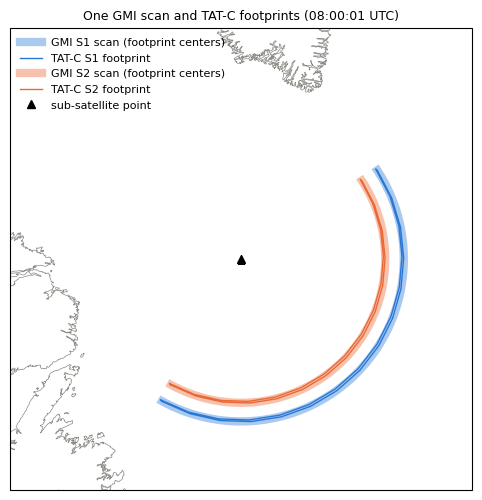

In [7]:
k = i2[len(i2) // 3]
track = orbit.get_orbit_track(to_utc(scan_time[k]))
projection = ccrs.AzimuthalEquidistant(central_longitude=float(sub_lon[len(i2) // 3]), central_latitude=float(sub_lat[len(i2) // 3]))
fig, ax = plt.subplots(figsize=(6.5, 6), subplot_kw={"projection": projection})
for feed in FEEDS:
    ax.plot(foot[feed][0][k], foot[feed][1][k], color=FEED_COLORS[feed], lw=6, alpha=0.4, transform=ccrs.Geodetic(), label=f"GMI {feed} scan (footprint centers)")
    footprint = instruments[feed].compute_footprint(track)[0]
    for part in getattr(footprint, "geoms", [footprint]):
        ax.plot(*part.exterior.xy, color=FEED_COLORS[feed], lw=1, transform=ccrs.Geodetic(), label=f"TAT-C {feed} footprint")
ax.plot(sub_lon[len(i2) // 3], sub_lat[len(i2) // 3], "k^", transform=ccrs.Geodetic(), label="sub-satellite point")
ax.coastlines(color=GRAY, linewidth=0.5)
ax.set_extent([-750e3, 750e3, -750e3, 750e3], crs=projection)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), frameon=False, fontsize=8, loc="upper left")
ax.set_title(f"One GMI scan and TAT-C footprints ({DAY + timedelta(seconds=float(scan_time[k])):%H:%M:%S} UTC)", fontsize=9)
plt.show()

Both conical instruments' footprints follow their scanned arcs, and their swath widths, computed from the cone angle, scan sector, and altitude, are within 0.1 km (median) and 0.4 km (95th percentile) of the observed end-to-end distances. The model built for AMSR2 needs nothing more than the two feeds' measured parameters to describe GMI.

## Test 4: Observations

`collect_observations` is evaluated for the points of a Fibonacci lattice with a typical spacing of 500 km within the latitudes GMI observes (about 70 deg south to 70 deg north).

**Observed.** For each feed, a point is observed on a pass if it lies within a quadrilateral cell of footprint centers (adjacent samples on consecutive scans) next to one of its eight nearest footprints. (Near the ends of the arc, consecutive scans overlap at a shallow angle, and the cell containing a point need not be next to its nearest footprint.) Its observation time is the time at which it crosses the feed's cone ahead of the spacecraft, computed by bisection on the reported spacecraft trajectory near the nearest scan.

**Predicted.** Each feed's conical instrument, and for comparison a nadir `Instrument` whose field of regard is twice the feed's cone angle (whose `start` is the time a point enters that cone), as in the AMSR2 notebook. Observations are matched to observed passes of the same point within 10 minutes; predictions during data gaps are excluded.

In [8]:
def make_in_cell(unit):
    def in_cell(points, k, j):
        valid_cell = (k >= 0) & (k < len(scan_time) - 1) & (j >= 0) & (j < N_SAMPLES - 1)
        k, j = np.clip(k, 0, len(scan_time) - 2), np.clip(j, 0, N_SAMPLES - 2)
        valid_cell &= np.diff(scan_time)[k] < 3
        corners = [unit[k, j], unit[k, j + 1], unit[k + 1, j + 1], unit[k + 1, j]]
        signs = np.stack([np.sum(np.cross(p, q) * points, axis=-1) for p, q in zip(corners, corners[1:] + corners[:1])])
        return valid_cell & (np.all(signs >= 0, axis=0) | np.all(signs <= 0, axis=0))

    return in_cell


def cone_crossing(target, k, cone_angle):
    """Time (s) at which a target crosses a cone near scan k, by bisection on the reported trajectory."""

    def angle(t):
        i = int(np.clip(np.searchsorted(scan_time, t) - 1, 0, len(scan_time) - 2))
        f = (t - scan_time[i]) / (scan_time[i + 1] - scan_time[i])
        position = sc_pos[i] + f * (sc_pos[i + 1] - sc_pos[i])
        lon, lat, _ = TO_GEODETIC.transform(*position)
        return np.degrees(np.arccos(np.dot(normalize(target - position), -up(lon, lat)))) - cone_angle

    lower, upper = scan_time[k] - 6, scan_time[k] + 6
    if angle(lower) * angle(upper) > 0:
        return np.nan
    for _ in range(30):
        middle = (lower + upper) / 2
        lower, upper = (middle, upper) if angle(middle) > 0 else (lower, middle)
    return (lower + upper) / 2


points4 = generate_points_fibonacci_lattice(500e3)
points4 = points4[np.abs(points4.geometry.y) < 72].reset_index(drop=True)
point_unit = up(points4.geometry.x.to_numpy(), points4.geometry.y.to_numpy())


def in_gap(times):
    return np.any([(times >= pd.Timestamp(DAY) + pd.Timedelta(seconds=a)) & (times <= pd.Timestamp(DAY) + pd.Timedelta(seconds=b)) for a, b in gaps], axis=0) if gaps else np.zeros(len(times), dtype=bool)


observed4, rows4, matched4 = {}, {}, {}
start4, end4 = DAY + timedelta(seconds=float(scan_time[0])), DAY + timedelta(seconds=float(scan_time[-1]))
for index, feed in enumerate(FEEDS):
    unit = up(*foot[feed])
    in_cell = make_in_cell(unit)
    tree = cKDTree(unit.reshape(-1, 3))
    rows = []
    for p, hits in enumerate(tree.query_ball_point(point_unit, r=2 * np.sin(40 / 6371 / 2), workers=-1)):
        if not hits:
            continue
        hits = np.array(hits)
        k_all = hits // N_SAMPLES
        order = np.argsort(scan_time[k_all])
        hits, k_all = hits[order], k_all[order]
        for group in np.split(np.arange(len(hits)), np.nonzero(np.diff(scan_time[k_all]) > 600)[0] + 1):
            nearest = hits[group][np.argsort(np.linalg.norm(unit.reshape(-1, 3)[hits[group]] - point_unit[p], axis=-1))[:8]]
            k, j = divmod(int(nearest[0]), N_SAMPLES)
            if not any(
                in_cell(point_unit[[p]], np.array([n // N_SAMPLES + dk]), np.array([n % N_SAMPLES + dj]))[0]
                for n in nearest
                for dk in (-1, 0)
                for dj in (-1, 0)
            ):
                continue
            crossing = cone_crossing(ecef(points4.geometry.x.iloc[p], points4.geometry.y.iloc[p]), k, geometry[feed]["cone"])
            if np.isfinite(crossing):
                rows.append({"point_id": p, "time": pd.Timestamp(DAY) + pd.Timedelta(seconds=float(crossing)), "azimuth": float(geometry[feed]["azimuth"][j])})
    observed4[feed] = pd.DataFrame(rows).astype({"point_id": "int64"})
    models = {
        "conical instrument": (gpm, index, "epoch"),
        "cone field of regard": (gpm.model_copy(update={"instruments": [Instrument(name="cone", field_of_regard=2 * geometry[feed]["cone"])]}), 0, "start"),
    }
    for model, (satellite, instrument_index, column) in models.items():
        predicted = pd.concat(
            [
                collect_observations(Point(id=p, latitude=g.y, longitude=g.x), satellite, start4, end4, instrument_index)
                for p, g in enumerate(points4.geometry)
            ]
        ).reset_index(drop=True)
        predicted["point_id"] = predicted.point_id.astype("int64")
        predicted = predicted[~in_gap(predicted.epoch)]
        merged = pd.merge_asof(
            observed4[feed].sort_values("time"),
            predicted[["point_id", column]].rename(columns={column: "predicted"}).sort_values("predicted"),
            left_on="time", right_on="predicted", by="point_id", direction="nearest", tolerance=pd.Timedelta(minutes=10),
        )
        hit = merged.predicted.notna()
        dt = (merged.predicted - merged.time).dt.total_seconds()
        matched4[(feed, model)] = merged
        rows4[(f"{feed} ({FEEDS[feed]})", f"{model}, {column}")] = {
            "observed": len(observed4[feed]),
            "predicted": len(predicted),
            "matched": int(hit.sum()),
            "observed only": int((~hit).sum()),
            "predicted only": len(predicted) - int(hit.sum()),
            "time, median (s)": np.median(dt[hit]),
            "time, p95 |x| (s)": np.percentile(np.abs(dt[hit]), 95),
        }
pd.DataFrame(rows4).T.round(2)

observed  predicted  matched  \
S1 (low frequency)  conical instrument, epoch      3093.0     3084.0   3084.0   
                    cone field of regard, start    3093.0     3200.0   3093.0   
S2 (high frequency) conical instrument, epoch      2730.0     2725.0   2724.0   
                    cone field of regard, start    2730.0     2831.0   2730.0   

                                                 observed only  \
S1 (low frequency)  conical instrument, epoch              9.0   
                    cone field of regard, start            0.0   
S2 (high frequency) conical instrument, epoch              6.0   
                    cone field of regard, start            0.0   

                                                 predicted only  \
S1 (low frequency)  conical instrument, epoch               0.0   
                    cone field of regard, start           107.0   
S2 (high frequency) conical instrument, epoch               1.0   
                    cone field of regard, start           101.0   

                                                 time, median (s)  \
S1 (low frequency)  conical instrument, epoch                0.56   
                    cone field of regard, start              0.38   
S2 (high frequency) conical instrument, epoch                0.56   
                    cone field of regard, start              0.42   

                                                 time, p95 |x| (s)  
S1 (low frequency)  conical instrument, epoch                 0.69  
                    cone field of regard, start               0.66  
S2 (high frequency) conical instrument, epoch                 0.68  
                    cone field of regard, start               0.65

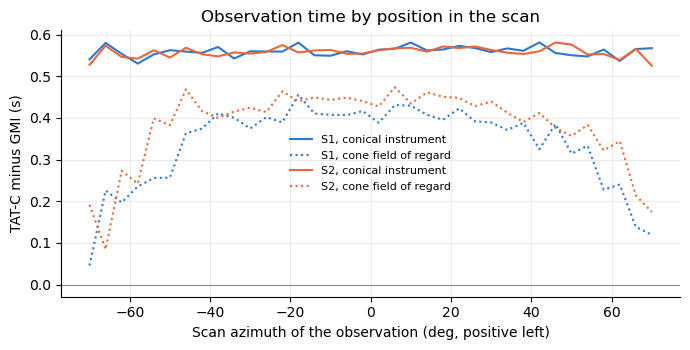

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.6))
edges4 = np.arange(-72, 73, 4)
for (feed, model), merged in matched4.items():
    hit = merged.predicted.notna()
    q = binned(merged.azimuth[hit].to_numpy(), (merged.predicted - merged.time).dt.total_seconds()[hit].to_numpy(), edges4)
    ax.plot((edges4[:-1] + edges4[1:]) / 2, q[:, 1], color=FEED_COLORS[feed], ls="-" if model == "conical instrument" else ":", label=f"{feed}, {model}")
ax.axhline(0, color=GRAY, lw=0.8)
ax.set(xlabel="Scan azimuth of the observation (deg, positive left)", ylabel="TAT-C minus GMI (s)", title="Observation time by position in the scan")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The conical instruments predict 99.7% of the passes observed by the low-frequency feed (3,084 of 3,093) and 99.8% of those observed by the high-frequency feed (2,724 of 2,730), with a single extra prediction. Their epochs follow the observation times by 0.56 s (median) and by no more than 0.69 s (95th percentile), uniformly across the scan. The offset is the orbit's: TAT-C's satellite trails GPM by 4.2 km (Test 1), or about 0.6 s, so the times are otherwise consistent to about 0.1 s.

This test exposed an error in the access periods within which `collect_observations` searches for cone crossings. Over a full day, Skyfield's `find_events` returned some rise and set times several seconds late, and passes whose cone crossing came within a few seconds of the start of the access period were missed (about 1.5% of the passes, mostly near GPM's northernmost latitudes). TAT-C now refines rise and set times to within a millisecond.

The cone field of regard, with twice the cone angle, matches every observed pass but predicts 3.5% more passes than were observed: its circle extends beyond the scan sector at the swath edges. Its `start` is within 0.66 s of the observation times (95th percentile), slightly earlier than the conical instrument's epoch toward the swath edges, because the access period is derived from a conservative (apogee altitude, spherical Earth) elevation angle.

## Test 5: Swath Coverage

Over one orbit (starting at 12:00 UTC), the area scanned by each feed (the union of quadrilaterals of footprint centers on consecutive scans, tested as in Test 4) is compared with the union of its conical instrument's footprints from `compute_ground_track`, at time steps of 1.875 s (one scan), 10 s, and 30 s, with the along-track field of view tailored to each time step (the angle subtended at nadir by the distance the ground track advances in one time step), on a 0.1 deg grid. As in the other notebooks, the comparison is limited to grid cells within 300 km of a footprint scanned at least 60 s after the start and before the end of the orbit.

In [10]:
orbit_start = 12 * 3600
orbit_period = 86400 / float(TLE[1][52:63])
scans5 = np.nonzero((scan_time >= orbit_start) & (scan_time < orbit_start + orbit_period))[0]
STEP5, MARGIN5 = 0.1, 60  # deg, s
lon5, lat5 = np.meshgrid(np.arange(-180 + STEP5 / 2, 180, STEP5), np.arange(-90 + STEP5 / 2, 90, STEP5))
cell_area5 = (np.cos(np.radians(lat5)) * (STEP5 * 111.32) ** 2).ravel()
grid5 = up(lon5.ravel(), lat5.ravel())
ground_speed5 = 2 * np.pi * 6371.0088e3 / orbit_period
altitude5 = float(np.median(gmi["sc_alt"])) * 1e3
rows5 = {}
for feed in FEEDS:
    unit = up(*foot[feed])
    in_cell = make_in_cell(unit)
    tree5 = cKDTree(unit[scans5].reshape(-1, 3))
    distance5, nearest5 = tree5.query(grid5, workers=-1)
    nearest_time5 = scan_time[scans5][nearest5 // N_SAMPLES] - scan_time[scans5[0]]
    duration5 = scan_time[scans5[-1]] - scan_time[scans5[0]]
    compared5 = (distance5 < 2 * np.sin(300 / 6371 / 2)) & (nearest_time5 > MARGIN5) & (nearest_time5 < duration5 - MARGIN5)
    observed5 = np.zeros(len(grid5), dtype=bool)
    _, nearest_eight = tree5.query(grid5[compared5], k=8, workers=-1)
    for column in range(8):
        k, j = np.divmod(nearest_eight[:, column], N_SAMPLES)
        k = scans5[k]
        inside = np.zeros(len(k), dtype=bool)
        for dk in (-1, 0):
            for dj in (-1, 0):
                inside |= in_cell(grid5[compared5], k + dk, j + dj)
        observed5[np.flatnonzero(compared5)] |= inside
    for time_step in [1.875, 10, 30]:
        width = np.degrees(2 * np.arctan(ground_speed5 * time_step / 2 / altitude5))
        first, last = scan_time[scans5[0]], scan_time[scans5[-1]]
        times = to_utc(first + time_step * (np.arange(int((last - first) // time_step)) + 0.5))
        instrument = instruments[feed].model_copy(update={"along_track_field_of_view": width})
        geometry5 = compute_ground_track(gpm.model_copy(update={"instruments": [instrument]}), times).geometry.iloc[0]
        prepare(geometry5)
        predicted = np.zeros(len(grid5), dtype=bool)
        predicted[compared5] = contains_xy(geometry5, lon5.ravel()[compared5], lat5.ravel()[compared5])
        area = lambda mask: np.sum(mask * cell_area5) / 1e6
        rows5[(f"{feed} ({FEEDS[feed]})", f"{time_step:g} s ({width:.2f} deg along track)")] = {
            "observed (10^6 km^2)": area(observed5),
            "TAT-C (10^6 km^2)": area(predicted),
            "IoU": area(observed5 & predicted) / area(observed5 | predicted),
            "observed only (%)": 100 * area(observed5 & ~predicted) / area(observed5),
            "TAT-C only (%)": 100 * area(predicted & ~observed5) / area(predicted),
        }
pd.DataFrame(rows5).T.round(3)

observed (10^6 km^2)  \
S1 (low frequency)  1.875 s (1.75 deg along track)                38.520   
                    10 s (9.30 deg along track)                   38.520   
                    30 s (27.41 deg along track)                  38.520   
S2 (high frequency) 1.875 s (1.75 deg along track)                34.123   
                    10 s (9.30 deg along track)                   34.123   
                    30 s (27.41 deg along track)                  34.123   

                                                    TAT-C (10^6 km^2)    IoU  \
S1 (low frequency)  1.875 s (1.75 deg along track)             38.522  1.000   
                    10 s (9.30 deg along track)                38.525  0.999   
                    30 s (27.41 deg along track)               38.557  0.999   
S2 (high frequency) 1.875 s (1.75 deg along track)             34.126  0.999   
                    10 s (9.30 deg along track)                34.129  0.999   
                    30 s (27.41 deg along track)               34.154  0.999   

                                                    observed only (%)  \
S1 (low frequency)  1.875 s (1.75 deg along track)              0.021   
                    10 s (9.30 deg along track)                 0.019   
                    30 s (27.41 deg along track)                0.009   
S2 (high frequency) 1.875 s (1.75 deg along track)              0.022   
                    10 s (9.30 deg along track)                 0.018   
                    30 s (27.41 deg along track)                0.010   

                                                    TAT-C only (%)  
S1 (low frequency)  1.875 s (1.75 deg along track)           0.026  
                    10 s (9.30 deg along track)              0.032  
                    30 s (27.41 deg along track)             0.103  
S2 (high frequency) 1.875 s (1.75 deg along track)           0.031  
                    10 s (9.30 deg along track)              0.037  
                    30 s (27.41 deg along track)             0.102

Each conical instrument's swath matches the area its feed scans over an orbit with an IoU of 0.999 or better at every time step: less than 0.03% of the scanned area lies outside the TAT-C swath, and at most 0.1% of the TAT-C swath lies outside the scanned area (at the 30 s step, where the footprints are longest). Unlike for AMSR2, no gaps between consecutive footprints are apparent.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (CelesTrak TLE vs. reported position) | 4.2 km behind along track (median), within 0.5 km across track and radially, a day or more before the TLE epoch |
| 2. Scan geometry | constant cone angles of 48.46 deg (low frequency) and 45.28 deg (high frequency); both scan 76.0 deg on either side of a center 0.3 deg right of the *inertial* velocity; arcs 522 and 462 km ahead of nadir; swaths 1,012 and 897 km |
| 3. Footprints | conical instrument footprints follow both arcs; swath width within 0.1 km (median) and 0.4 km (95th percentile) |
| 4. Observations (`collect_observations`) | conical instruments: 99.7 and 99.8% of passes matched, one extra, `epoch` 0.56 s late (the orbit offset) and within 0.69 s (95th percentile); cone field of regard: all passes matched, 3.5% extra |
| 5. Swath coverage (`compute_ground_track`) | IoU of 0.999 or better for both feeds at time steps from 1.875 to 30 s |

**Generality of the conical instrument.** The `ConicalInstrument` was developed against AMSR2; GMI tests it on a different orbit (non-sun-synchronous, 65 deg inclination, 440 km altitude) and with two feeds. Two conical instruments on one satellite, each with its measured cone angle and the common scan sector, in the inertial velocity frame, reproduce the observed passes, their times to within the orbit error, the swath widths to within half a kilometer, and the scanned areas at any time step tested. No change to the model was needed.

**Access periods.** The comparison of observation times found that the rise and set times from Skyfield's `find_events`, which bound the access periods of `collect_observations` for every instrument, could be several seconds in error over long analysis periods. They are now refined to within a millisecond. The error mattered most for conical instruments, whose cone crossings lie close to the start of the access period.